In [1]:
!pip install ultralytics --quiet

In [15]:
import numpy as np
import os
import random
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
import yaml
import gc
import torch

In [3]:
import kagglehub

path = kagglehub.dataset_download("saathvik16/bdd10k-object-detection-with-yolo-format-labels")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/saathvik16/bdd10k-object-detection-with-yolo-format-labels


In [4]:
data_yaml_content = """
train:  /kaggle/input/datasets/saathvik16/bdd10k-object-detection-with-yolo-format-labels/dataset/train/images
val: /kaggle/input/datasets/saathvik16/bdd10k-object-detection-with-yolo-format-labels/dataset/val/images
test: /kaggle/input/datasets/saathvik16/bdd10k-object-detection-with-yolo-format-labels/dataset/test/images

nc: 10

names:
  0: bike
  1: bus
  2: car
  3: motor
  4: person
  5: rider
  6: traffic light
  7: traffic sign
  8: train
  9: truck
"""
dataset_yaml_path = '/kaggle/working/data.yaml'
with open(dataset_yaml_path, 'w') as f:
    f.write(data_yaml_content)

print(f"data.yaml created at: {dataset_yaml_path}")

data.yaml created at: /kaggle/working/data.yaml


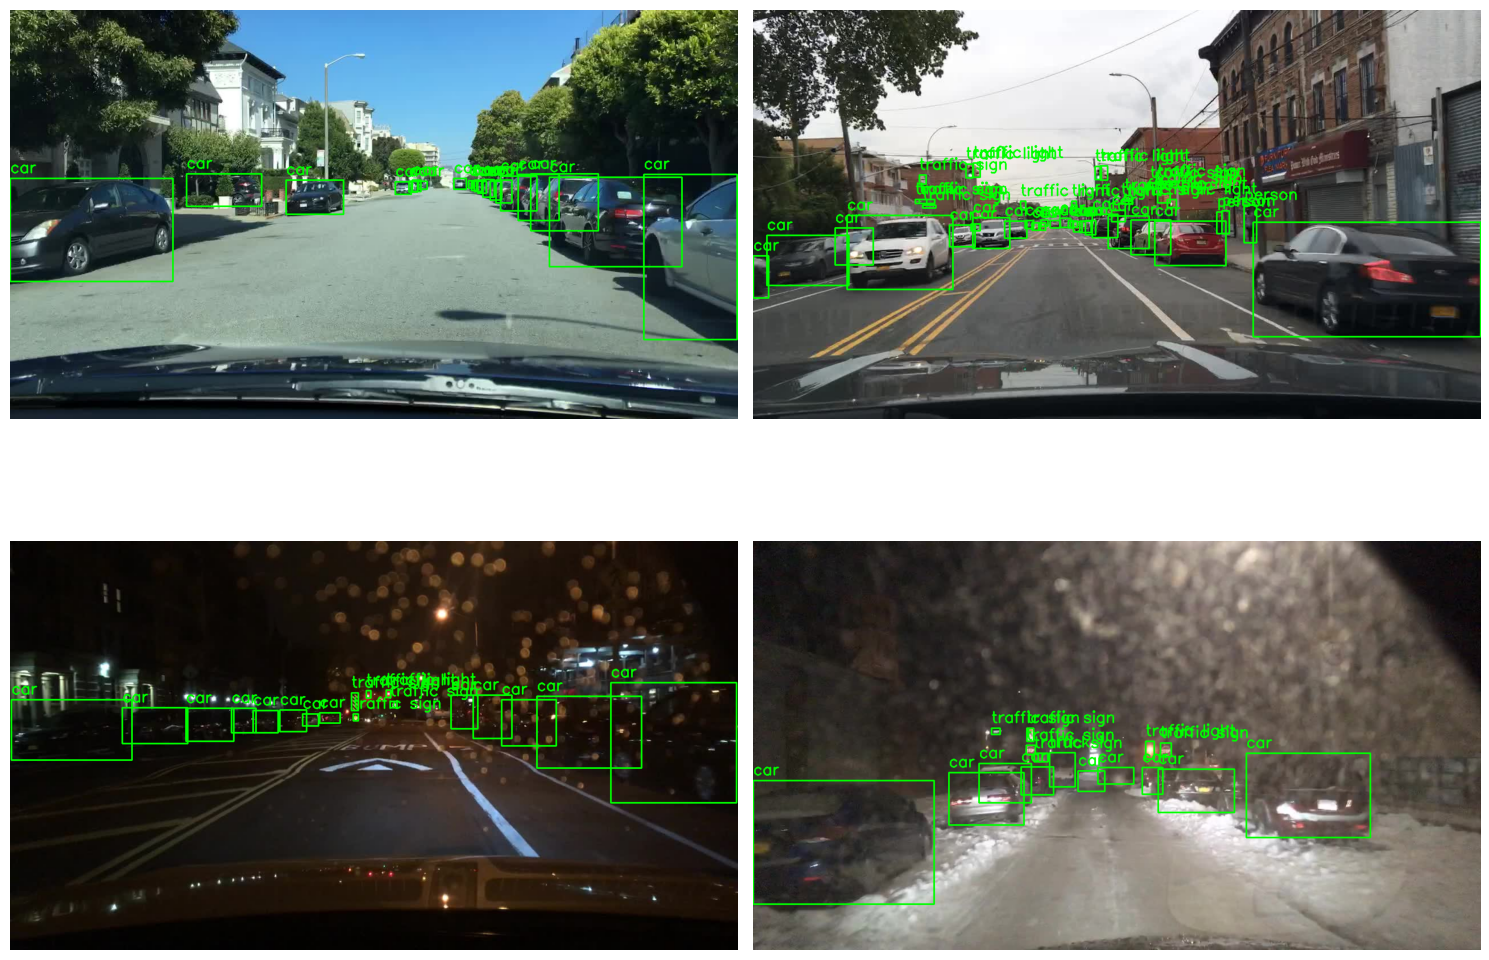

In [5]:
img_dir = '/kaggle/input/datasets/saathvik16/bdd10k-object-detection-with-yolo-format-labels/dataset/train/images'
label_dir = '/kaggle/input/datasets/saathvik16/bdd10k-object-detection-with-yolo-format-labels/dataset/train/labels'

class_names = [
    'bike', 'bus', 'car', 'motor', 'person', 'rider', 
    'traffic light', 'traffic sign', 'train', 'truck'
]

num_images_to_show = 4

image_files = os.listdir(img_dir)
random_images = random.sample(image_files, num_images_to_show)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten() 

for i, img_filename in enumerate(random_images):
    img_path = os.path.join(img_dir, img_filename)
    label_path = os.path.join(label_dir, os.path.splitext(img_filename)[0] + '.txt')

    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) 
    h, w, _ = image.shape

    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f.readlines():
                parts = line.strip().split()
                class_id = int(parts[0])
                x_center, y_center, box_width, box_height = map(float, parts[1:])

                abs_x_center = x_center * w
                abs_y_center = y_center * h
                abs_width = box_width * w
                abs_height = box_height * h

                x1 = int(abs_x_center - (abs_width / 2))
                y1 = int(abs_y_center - (abs_height / 2))
                x2 = int(x1 + abs_width)
                y2 = int(y1 + abs_height)

                label = class_names[class_id]
                cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)

                cv2.putText(image, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

    axes[i].imshow(image)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [6]:
model = YOLO('yolov8m.yaml')
model.load('yolov8m.pt')

Transferred 475/475 items from pretrained weights


YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(48, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(48, 96, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(96, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(96, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(96, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(192, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(96, eps=0.001, momentum=0.03, affine=True, track_running_

In [7]:
results = model.train(data='/kaggle/working/data.yaml', epochs=1, imgsz=640, batch=64)

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.yaml, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train5, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.

In [8]:
results = model.val(
    data='/kaggle/working/data.yaml',
    split='test',                    
    imgsz=640,
    batch=64
)

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8m summary (fused): 93 layers, 25,845,550 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 120.4±63.4 MB/s, size: 70.0 KB)
val: Scanning /kaggle/input/datasets/saathvik16/bdd10k-object-detection-with-yolo-format-labels/dataset/test/labels... 2000 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2000/2000 609.7it/s 3.3s0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/saathvik16/bdd10k-object-detection-with-yolo-format-labels/dataset/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 32/32 1.2s/it 37.3s1.2ss
                   all       2000      36678      0.612      0.315      0.326      0.166
                  bike        139        214      0.417      0.262      0.231     0.0864
                   bus        264        339      0.317      0.342       0.

In [16]:
del model
gc.collect()
torch.cuda.empty_cache()

In [17]:
model = YOLO('yolov8l.yaml')
model.load('yolov8l.pt')

Transferred 595/595 items from pretrained weights


YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(128, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(128, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(320, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(128, eps=0.001, momentum=0.03, affine=True, track_r

In [18]:
results = model.train(data='/kaggle/working/data.yaml', epochs=1, imgsz=640, batch=64)

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8l.yaml, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train6, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.

In [19]:
results = model.val(
    data='/kaggle/working/data.yaml',
    split='test',                    
    imgsz=640,
    batch=64
)

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8l summary (fused): 113 layers, 43,614,318 parameters, 0 gradients, 164.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 125.8±43.3 MB/s, size: 55.0 KB)
val: Scanning /kaggle/input/datasets/saathvik16/bdd10k-object-detection-with-yolo-format-labels/dataset/test/labels... 2000 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2000/2000 817.7it/s 2.4s0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/saathvik16/bdd10k-object-detection-with-yolo-format-labels/dataset/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 32/32 1.8s/it 56.8s1.7ss
                   all       2000      36678      0.504      0.312      0.318      0.162
                  bike        139        214      0.318      0.248      0.195       0.07
                   bus        264        339      0.309      0.354       

In [20]:
del model
gc.collect()
torch.cuda.empty_cache()

In [21]:
model = YOLO('yolov8x.yaml')
model.load('yolov8x.pt')

Transferred 595/595 items from pretrained weights


YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 80, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(80, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(80, 160, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(160, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(160, 160, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(160, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(400, 160, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(160, eps=0.001, momentum=0.03, affine=True, track_r

In [22]:
results = model.train(data='/kaggle/working/data.yaml', epochs=1, imgsz=640, batch=64)

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8x.yaml, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train7, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.

In [23]:
results = model.val(
    data='/kaggle/working/data.yaml',
    split='test',                    
    imgsz=640,
    batch=64
)

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8x summary (fused): 113 layers, 68,133,198 parameters, 0 gradients, 257.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 108.9±35.6 MB/s, size: 55.0 KB)
val: Scanning /kaggle/input/datasets/saathvik16/bdd10k-object-detection-with-yolo-format-labels/dataset/test/labels... 2000 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2000/2000 821.7it/s 2.4s<0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/saathvik16/bdd10k-object-detection-with-yolo-format-labels/dataset/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 32/32 2.6s/it 1:242.6sss
                   all       2000      36678       0.46      0.318      0.305      0.155
                  bike        139        214      0.128      0.271      0.138     0.0533
                   bus        264        339      0.359      0.265      

In [24]:
del model
gc.collect()
torch.cuda.empty_cache()

In [32]:
with open('/kaggle/working/yolov8m_early.yaml', 'w') as f:
    f.write("""nc: 10
scales:
  m: [0.67, 0.75, 768]

# Backbone up to layer 6
backbone:
  - [-1, 1, Conv, [64, 3, 2]]      # 0-P1/2
  - [-1, 1, Conv, [128, 3, 2]]     # 1-P2/4
  - [-1, 3, C2f, [128, True]]      # 2
  - [-1, 1, Conv, [256, 3, 2]]     # 3-P3/8
  - [-1, 6, C2f, [256, True]]      # 4 <- P3 features
  - [-1, 1, Conv, [512, 3, 2]]     # 5-P4/16
  - [-1, 6, C2f, [512, True]]      # 6 <- EXIT POINT

# Dual-scale detection head (P3 and P4)
head:
  # P4 branch (from layer 6)
  - [-1, 1, Conv, [384, 3, 1]]     # 7 - reduce channels
  - [-1, 1, Conv, [384, 3, 1]]     # 8 - refine features
  
  # P3 branch (upsample and concat with layer 4)
  - [-1, 1, nn.Upsample, [None, 2, "nearest"]]  # 9
  - [[-1, 4], 1, Concat, [1]]                   # 10 - cat P3 from layer 4
  - [-1, 2, C2f, [256]]                         # 11 - process P3
  
  # P4 processing (from upsampled features)
  - [8, 1, Conv, [512, 3, 1]]                   # 12 - final P4 refinement
  
  # Dual-scale detection
  - [[11, 12], 1, Detect, [nc]]                 # 13 - Detect(P3, P4)
""")

In [33]:
model = YOLO('/kaggle/working/yolov8m_early.yaml')

In [34]:
results = model.train(data='/kaggle/working/data.yaml', epochs=1, imgsz=640, batch=64)

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/kaggle/working/yolov8m_early.yaml, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train9, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patien

In [35]:
results = model.val(
    data='/kaggle/working/data.yaml',
    split='test',                    
    imgsz=640,
    batch=64
)

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8m_early summary (fused): 53 layers, 10,172,036 parameters, 0 gradients, 60.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 144.6±76.1 MB/s, size: 76.4 KB)
val: Scanning /kaggle/input/datasets/saathvik16/bdd10k-object-detection-with-yolo-format-labels/dataset/test/labels... 2000 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2000/2000 845.2it/s 2.4s0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/saathvik16/bdd10k-object-detection-with-yolo-format-labels/dataset/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 32/32 1.1it/s 29.8s0.9ss
                   all       2000      36678      0.431     0.0393     0.0262     0.0095
                  bike        139        214          1          0     0.0115    0.00198
                   bus        264        339          0          0   

In [36]:
del model
gc.collect()
torch.cuda.empty_cache()

In [37]:
with open('/kaggle/working/yolov8l_early.yaml', 'w') as f:
    f.write("""nc: 10
scales:
  l: [1.00, 1.00, 512]

# Backbone up to layer 6
backbone:
  - [-1, 1, Conv, [64, 3, 2]]      # 0-P1/2
  - [-1, 1, Conv, [128, 3, 2]]     # 1-P2/4
  - [-1, 3, C2f, [128, True]]      # 2
  - [-1, 1, Conv, [256, 3, 2]]     # 3-P3/8
  - [-1, 6, C2f, [256, True]]      # 4 <- P3 features
  - [-1, 1, Conv, [512, 3, 2]]     # 5-P4/16
  - [-1, 6, C2f, [512, True]]      # 6 <- EXIT POINT

# Dual-scale detection head (P3 and P4)
head:
  # P4 branch (from layer 6)
  - [-1, 1, Conv, [384, 3, 1]]     # 7 - reduce channels
  - [-1, 1, Conv, [384, 3, 1]]     # 8 - refine features
  
  # P3 branch (upsample and concat with layer 4)
  - [-1, 1, nn.Upsample, [None, 2, "nearest"]]  # 9
  - [[-1, 4], 1, Concat, [1]]                   # 10 - cat P3 from layer 4
  - [-1, 2, C2f, [256]]                         # 11 - process P3
  
  # P4 processing (from upsampled features)
  - [8, 1, Conv, [512, 3, 1]]                   # 12 - final P4 refinement
  
  # Dual-scale detection
  - [[11, 12], 1, Detect, [nc]]                 # 13 - Detect(P3, P4)
""")

In [38]:
model = YOLO('/kaggle/working/yolov8l_early.yaml')

In [39]:
results = model.train(data='/kaggle/working/data.yaml', epochs=1, imgsz=640, batch=64)

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/kaggle/working/yolov8l_early.yaml, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train10, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patie

In [40]:
results = model.val(
    data='/kaggle/working/data.yaml',
    split='test',                    
    imgsz=640,
    batch=64
)

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8l_early summary (fused): 65 layers, 21,555,108 parameters, 0 gradients, 130.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 107.4±41.1 MB/s, size: 55.0 KB)
val: Scanning /kaggle/input/datasets/saathvik16/bdd10k-object-detection-with-yolo-format-labels/dataset/test/labels... 2000 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2000/2000 716.6it/s 2.8s0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/saathvik16/bdd10k-object-detection-with-yolo-format-labels/dataset/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 32/32 1.4s/it 45.9s1.4ss
                   all       2000      36678      0.564     0.0452     0.0736     0.0223
                  bike        139        214          1          0    0.00482    0.00121
                   bus        264        339          1          0  

In [41]:
del model
gc.collect()
torch.cuda.empty_cache()

In [45]:
with open('/kaggle/working/yolov8x_early.yaml', 'w') as f:
    f.write("""nc: 10
scales:
  x: [1.00, 1.25, 512]

# Backbone up to layer 6
backbone:
  - [-1, 1, Conv, [64, 3, 2]]      # 0-P1/2
  - [-1, 1, Conv, [128, 3, 2]]     # 1-P2/4
  - [-1, 3, C2f, [128, True]]      # 2
  - [-1, 1, Conv, [256, 3, 2]]     # 3-P3/8
  - [-1, 6, C2f, [256, True]]      # 4 <- P3 features
  - [-1, 1, Conv, [512, 3, 2]]     # 5-P4/16
  - [-1, 6, C2f, [512, True]]      # 6 <- EXIT POINT

# Dual-scale detection head (P3 and P4)
head:
  # P4 branch (from layer 6)
  - [-1, 1, Conv, [384, 3, 1]]     # 7 - reduce channels
  - [-1, 1, Conv, [384, 3, 1]]     # 8 - refine features
  
  # P3 branch (upsample and concat with layer 4)
  - [-1, 1, nn.Upsample, [None, 2, "nearest"]]  # 9
  - [[-1, 4], 1, Concat, [1]]                   # 10 - cat P3 from layer 4
  - [-1, 2, C2f, [256]]                         # 11 - process P3
  
  # P4 processing (from upsampled features)
  - [8, 1, Conv, [512, 3, 1]]                   # 12 - final P4 refinement
  
  # Dual-scale detection
  - [[11, 12], 1, Detect, [nc]]                 # 13 - Detect(P3, P4)
""")

In [46]:
model = YOLO('/kaggle/working/yolov8x_early.yaml')

In [47]:
results = model.train(data='/kaggle/working/data.yaml', epochs=1, imgsz=640, batch=64)

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/kaggle/working/yolov8x_early.yaml, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train11, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patie

In [48]:
results = model.val(
    data='/kaggle/working/data.yaml',
    split='test',                    
    imgsz=640,
    batch=64
)

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8x_early summary (fused): 65 layers, 33,671,524 parameters, 0 gradients, 204.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 91.9±26.7 MB/s, size: 55.0 KB)
val: Scanning /kaggle/input/datasets/saathvik16/bdd10k-object-detection-with-yolo-format-labels/dataset/test/labels... 2000 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2000/2000 646.3it/s 3.1s<0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/saathvik16/bdd10k-object-detection-with-yolo-format-labels/dataset/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 32/32 2.1s/it 1:082.1s5s
                   all       2000      36678      0.587     0.0503      0.045     0.0193
                  bike        139        214          1          0    0.00541    0.00145
                   bus        264        339          1          0  

In [49]:
del model
gc.collect()
torch.cuda.empty_cache()

In [56]:
import torch
import torch.nn as nn
import time
from torchvision import models

# -----------------------------
# 1. Recreate Architecture
# -----------------------------
def get_model():
    model = models.mobilenet_v3_small(weights=None)
    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, 1)
    return model

# -----------------------------
# 2. Load Saved Weights
# -----------------------------
model_path = "/kaggle/input/datasets/saathvik16/yolov8m-weights-trained-early-and-final/uep_regressor_100k.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = get_model()
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()

# -----------------------------
# 3. Dummy Input (Matches Training Size)
# -----------------------------
input_tensor = torch.randn(1, 3, 224, 224).to(device)

# -----------------------------
# 4. Warmup
# -----------------------------
with torch.no_grad():
    for _ in range(30):
        _ = model(input_tensor)

if device.type == "cuda":
    torch.cuda.synchronize()

# -----------------------------
# 5. Measure Proper GPU Latency
# -----------------------------
repetitions = 300

if device.type == "cuda":
    starter = torch.cuda.Event(enable_timing=True)
    ender = torch.cuda.Event(enable_timing=True)

    timings = []

    with torch.no_grad():
        for _ in range(repetitions):
            starter.record()
            _ = model(input_tensor)
            ender.record()
            torch.cuda.synchronize()
            timings.append(starter.elapsed_time(ender))

    avg_time = sum(timings) / len(timings)

else:
    start = time.time()
    with torch.no_grad():
        for _ in range(repetitions):
            _ = model(input_tensor)
    end = time.time()
    avg_time = (end - start) / repetitions * 1000

fps = 1000 / avg_time

print(f"\nDevice: {device}")
print(f"Forward pass time: {avg_time:.3f} ms")
print(f"Max theoretical FPS: {fps:.2f}")


Device: cuda
Forward pass time: 5.313 ms
Max theoretical FPS: 188.21
